# Experimento 06 · Un solo flip entre los fragmentos del peso repartido

Este es el experimento enfocado que propusiste: **la misma lectura original en base, A y B, y un solo bit elegido al azar dentro del grupo permitido de cada formato**.

| Formato | Grupo que puede atacarse | Posiciones físicas | Peso de un flip |
|---|---|---|---:|
| Base | Bit 5 original | 5 | 32 ppb |
| A | Sus dos fragmentos | 5, 9 | 16 ppb |
| B | Seis fragmentos derivados de los bits 4 y 5 originales | 4, 8, 5, 9, 10, 11 | 8 ppb |

El bit 3 de B ya pesaba 8 y queda fuera de estos seis fragmentos. Todos los grupos están fijados antes del ataque, sin consultar la lectura ni el estado de los bits. Una posición se elige uniformemente entre las permitidas.

**Qué cambia respecto al 05:** allí probábamos todas las 16 posiciones del campo, incluidos bits altos y reservados. Aquí el ataque está restringido a los grupos de la tabla. Por tanto, los conteos de los dos experimentos tienen distinto denominador y distinto modelo de atacante. Este experimento no permite concluir protección frente a un atacante que elija cualquier otra posición.

En B estamos atacando contribuciones procedentes de 16 y 32, tal como pediste; en base/A sólo la contribución de 32. Esta comparación evalúa ese protocolo concreto y no aísla únicamente la contribución original de 32.

Ejecuta las celdas en orden con `Python (lorawan11 .venv)`. Sólo se generan productos en `resultados/06/`. Los modelos y sus umbrales se reutilizan de disco; no hay entrenamiento.

## Paso 1. Empezar con la misma lectura: 60 ppb

`60 = 32 + 16 + 8 + 4`. Las contribuciones de 32 y 16 están encendidas, así que todos sus fragmentos también lo están. Un flip las apaga:

- Base: `60 − 32 = 28`.
- A: `60 − 16 = 44`, elijamos cualquiera de sus dos fragmentos.
- B: `60 − 8 = 52`, elijamos cualquiera de sus seis fragmentos.

**El azar no siempre cambia el valor recibido.** Si las posiciones elegibles tienen el mismo peso y el mismo estado, todas producen el mismo cambio.

Con **28 ppb**, en cambio, la contribución de 16 está encendida y la de 32 está apagada. En B, dos opciones restan 8 (resultado 20) y cuatro suman 8 (resultado 36). La dirección depende del estado previo, no la escoge el atacante.

La primera tabla siguiente muestra una elección por caso con semilla 42. La segunda enumera los resultados posibles y sus probabilidades; no son flips simultáneos.

In [1]:
from pathlib import Path
import sys
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

actual = Path.cwd().resolve()
RAIZ = next(p for p in (actual, *actual.parents)
            if (p / "experiments/cayenne_mod/flip_dirigido.py").is_file())
if str(RAIZ) not in sys.path:
    sys.path.insert(0,str(RAIZ))
from experiments.cayenne_mod import flip_dirigido
flip_dirigido = importlib.reload(flip_dirigido)

ej = flip_dirigido.ejemplos()
rng = np.random.default_rng(42)
selecciones = []
for (valor,formato), opciones in ej.groupby(["original","formato"],sort=False):
    elegida = opciones.iloc[int(rng.integers(len(opciones)))]
    selecciones.append(elegida)
print("Un solo bit seleccionado por lectura y formato:")
display(pd.DataFrame(selecciones)[["original","formato","bit","peso","recibido","delta"]].reset_index(drop=True))
print("Todos los resultados posibles (la probabilidad suma 1 por lectura y formato):")
display(ej.groupby(["original","formato","recibido","delta"],sort=False).prob_eleccion.sum().reset_index())

Un solo bit seleccionado por lectura y formato:


,original,formato,bit,peso,recibido,delta
0,60,base,5,32,28,-32
1,60,A,5,16,44,-16
2,60,B,10,8,52,-8
3,28,base,5,32,60,32
4,28,A,9,16,44,16
5,28,B,5,8,36,8


Todos los resultados posibles (la probabilidad suma 1 por lectura y formato):


,original,formato,recibido,delta,prob_eleccion
0,60,base,28,-32,1.000000
1,60,A,44,-16,1.000000
2,60,B,52,-8,1.000000
3,28,base,60,32,1.000000
4,28,A,44,16,1.000000
5,28,B,20,-8,0.333333
6,28,B,36,8,0.666667


## Paso 2. Repetir la comparación con las lecturas reales

Usamos los **35 704 mensajes de prueba** de los 27 detectores del notebook 09, con su predicción y p95 propios. Para cada mensaje:

1. Se parte de su mismo valor original en base, A y B.
2. Se elige **una sola posición** del grupo permitido de cada formato.
3. Se obtiene el valor recibido y se compara con la predicción guardada.
4. Se sustituye **sólo ese mensaje** en el día original para comprobar si cambia el máximo y su banda.
5. Se cuenta si ese cambio de decisión sucede sin alerta.

Cada fila es un escenario aislado. No se construye un día donde todos los mensajes estén atacados a la vez, ni se propagan ataques a perfiles futuros o a entradas de vecinos.

Se usa la misma lista de números uniformes por mensaje para emparejar los sorteos entre formatos. La semilla 42 permite repetir la selección, no la mejora. Un sorteo por mensaje deja **35 704 escenarios por formato**, también para B.

## Paso 3. Comprobar que el resultado no depende de un sorteo favorable

Además del sorteo, calculamos su **promedio exacto**: evaluamos cada opción por separado y le asignamos peso `1`, `1/2` o `1/6` en base, A y B. Al sumar esas probabilidades sobre los mensajes obtenemos cuántos escenarios dañinos se esperan en promedio si repitiéramos el sorteo. Ese número puede tener decimales.

Por ejemplo, si sólo una de las seis posiciones de B provoca daño para una lectura, su contribución al número esperado es `1/6`, no seis ataques ni un ataque garantizado. No comparamos sumas brutas de grupos de tamaños distintos.

La celda comprueba la transformación cifrada, los hashes de las fuentes, la coincidencia del caso base con el bit 5 del notebook 09 y dos ejecuciones idénticas antes de guardar. El análisis anual se hace aparte sin LSTM, porque el test sólo cubre 21/oct–31/dic/2025 y no tiene excedencias originales de 155 ppb.

In [2]:
from experiments.cayenne_mod.selectiva_red import validar_cifrado
n_cifrado = validar_cifrado()
print(f"{n_cifrado:,} transformaciones del FRMPayload verificadas.")
test, anual, info = flip_dirigido.construir(RAIZ)
test2, anual2, info2 = flip_dirigido.construir(RAIZ)
assert info == info2
for primero,segundo in [(test,test2),(anual,anual2)]:
    for nombre in primero:
        pd.testing.assert_frame_equal(primero[nombre],segundo[nombre],check_exact=True)
del test2,anual2
info["reproducibilidad"] = "Dos ejecuciones completas con tablas exactamente iguales"
info["verificaciones_cifrado"] = n_cifrado
DESTINO = flip_dirigido.guardar(RAIZ,test,anual,info)
print("Dos ejecuciones idénticas. Predicciones y p95 GUARDADOS; sin entrenamiento.")
print(f"Test: {info['test_mensajes']:,} mensajes, {info['test_dias']} días. Falsas alarmas limpias: {info['fpr_limpio_pct']:.2f}%.")
print(f"Productos guardados en {DESTINO.relative_to(RAIZ)}")

12,288 transformaciones del FRMPayload verificadas.


Dos ejecuciones idénticas. Predicciones y p95 GUARDADOS; sin entrenamiento.
Test: 35,704 mensajes, 72 días. Falsas alarmas limpias: 15.80%.
Productos guardados en experiments/cayenne_mod/resultados/06


## Paso 4. Leer primero el resultado del sorteo

**Cambio de banda** significa que el máximo diario observado pasa a otra categoría del proyecto. **Escapa** significa que ese escenario cambia la banda y no genera alerta. No basta con que el valor sea modificado o con que el LSTM no alerte.

Los días de la tabla son días que contienen alguna oportunidad seleccionada por el sorteo. No representan ataques ocurridos ni decisiones obtenidas atacando todos los mensajes juntos.

Después mostramos el promedio exacto para valorar el efecto sin depender de esa semilla. No sumar días de distintas posiciones ni interpretar el número esperado de escenarios como un número observado de días.

### Sorteo de una posición por mensaje, semilla 42

,formato,mensajes,peso_flip,daninos_sorteo,escapan_sorteo,dias_escape_sorteo
0,base,35704,32,928,228,16
3,A,35704,16,132,45,10
6,B,35704,8,29,12,6


### Promedio exacto del sorteo, independiente de la semilla

,formato,daninos_esperados,escapan_esperados,pct_escape_esperado,recall_global_esperado_pct,recall_dano_esperado_pct
0,base,928.0000,228.0000,0.6386,85.9512,75.4310
3,A,132.0000,45.0000,0.1260,44.4712,65.9091
6,B,24.3333,9.6667,0.0271,21.7128,60.2740


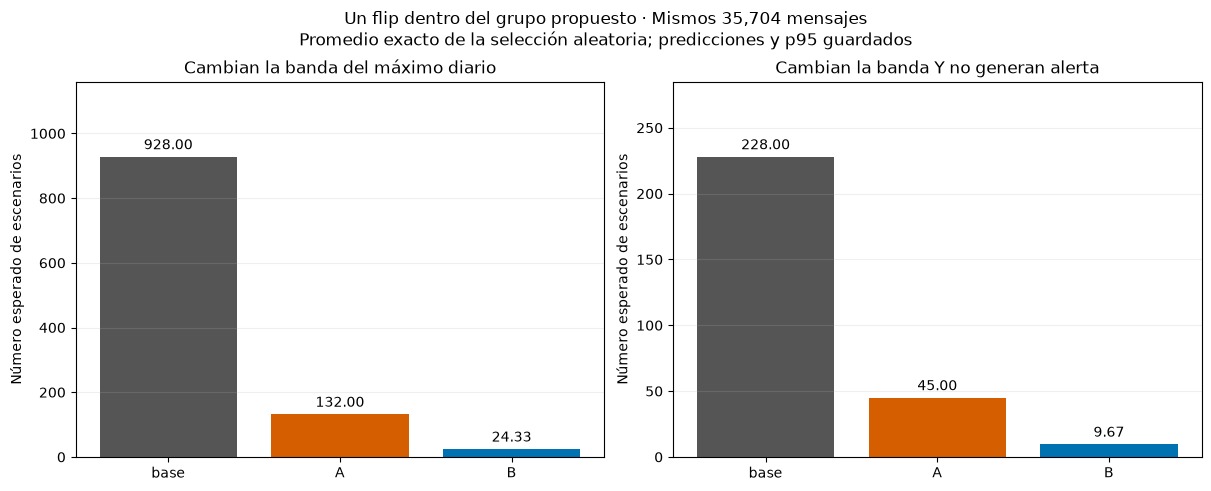

### Por qué: resultado de cada opción antes de promediar

,formato,bit,peso,prob_eleccion,daninos,escapan
0,base,5,32,1.0000,928,228
3,A,5,16,0.5000,132,45
4,A,9,16,0.5000,132,45
9,B,4,8,0.1667,13,1
10,B,8,8,0.1667,13,1
11,B,5,8,0.1667,30,14
12,B,9,8,0.1667,30,14
13,B,10,8,0.1667,30,14
14,B,11,8,0.1667,30,14


### Falsas excedencias de 155: otro daño, separado

,formato,daninos_sorteo,escapan_sorteo,daninos_esperados,escapan_esperados
1,base,46,0,46.0000,0.0
4,A,11,1,11.0000,1.0
7,B,1,0,0.6667,0.0


### Año completo SIN LSTM: ocultamiento de excedencias

,formato,mensajes,daninos_sorteo,daninos_esperados,dias_dano_sorteo,dias_con_alguna_opcion_danina
2,base,218823,2,2.0000,2,2
5,A,218823,2,2.0000,2,2
8,B,218823,1,0.3333,1,1


No hay casos originales ≥155 en el test LSTM. Los ocultamientos anuales no tienen evaluación de detección.


In [3]:
t = test["resumen"].query("tipo_dano == 'cambio_banda_red'")
display(Markdown("### Sorteo de una posición por mensaje, semilla 42"))
display(t[["formato","mensajes","peso_flip","daninos_sorteo","escapan_sorteo","dias_escape_sorteo"]])
display(Markdown("### Promedio exacto del sorteo, independiente de la semilla"))
display(t[["formato","daninos_esperados","escapan_esperados","pct_escape_esperado",
           "recall_global_esperado_pct","recall_dano_esperado_pct"]].round(4))
flip_dirigido.graficar(test,DESTINO)
plt.show()
display(Markdown("### Por qué: resultado de cada opción antes de promediar"))
display(test["por_opcion"].query("tipo_dano == 'cambio_banda_red'")[["formato","bit","peso","prob_eleccion","daninos","escapan"]].round(4))
display(Markdown("### Falsas excedencias de 155: otro daño, separado"))
display(test["resumen"].query("tipo_dano == 'falsa_fase1'")[["formato","daninos_sorteo","escapan_sorteo","daninos_esperados","escapan_esperados"]].round(4))
display(Markdown("### Año completo SIN LSTM: ocultamiento de excedencias"))
display(anual["resumen"].query("tipo_dano == 'anulada_fase1'")[["formato","mensajes","daninos_sorteo","daninos_esperados","dias_dano_sorteo","dias_con_alguna_opcion_danina"]].round(4))
print("No hay casos originales ≥155 en el test LSTM. Los ocultamientos anuales no tienen evaluación de detección.")

## Lectura de esta ejecución (02/oct/2026)

Los tres formatos parten de las mismas **35 704 lecturas**. Cada una recibe un único flip dentro de su grupo, en un escenario aislado.

| Formato | Cambian la banda en el sorteo | Cambian la banda y escapan al LSTM | Días con alguna oportunidad seleccionada que escapa |
|---|---:|---:|---:|
| Base | 928 | 228 | 16 |
| A | 132 | 45 | 10 |
| B | 29 | 12 | 6 |

El **promedio exacto** de cambios de banda que escapan es 228 para base, 45 para A y 9.67 para B. Base tiene una opción y las dos opciones de A producen el mismo valor recibido, de modo que sus conteos no dependen del sorteo. En B sí puede cambiar el sentido del flip según el grupo elegido; 12 es el resultado de la semilla 42 y 9.67 es el número medio esperado, no una cuenta literal de ataques fraccionarios.

Para verlo sin fórmulas complicadas:

- A tiene dos posiciones con 45 casos cada una, pero se elige **una**: el promedio es `(45 + 45) / 2 = 45`, no 90.
- B tiene dos posiciones con un caso cada una y cuatro con 14: el promedio es `(1 + 1 + 14 + 14 + 14 + 14) / 6 = 9.67`, no 58.

**El detector no mejoró su capacidad de descubrir las modificaciones pequeñas.** Su detección global esperada baja de 85.95 % a 44.47 % en A y 21.71 % en B. Lo que disminuye más es la cantidad de modificaciones capaces de cambiar la banda: el promedio exacto pasa de 928 a 132 y 24.33. Por eso termina quedando menos daño no detectado bajo este protocolo.

No todo objetivo mejora por igual. Para falsas excedencias de 155 no detectadas, base tiene 0, A tiene 1 y B tiene 0, tanto en este sorteo como en el promedio exacto. Cero aquí describe este periodo, no una garantía general.

En el año completo **sin LSTM**, el promedio exacto de escenarios de ocultamiento es 2 en base, 2 en A y 0.33 en B. La realización aleatoria dio 2, 2 y 1 respectivamente. No se atribuye detección a esos ocultamientos: el test con LSTM no tiene originales ≥155.

La comparación apoya que repartir el peso ayuda a reducir cambios de banda no detectados **frente al ataque restringido definido**, contando un intento por formato. No incluye atacar el bit 6, dos flips ni otros años, y B mezcla fragmentos de origen 16 y 32. La validación independiente sigue pendiente.

Fuentes: tablas y `protocolo.json` en `resultados/06/`. Predicciones y p95 guardados del notebook 09; no hubo entrenamiento. Dos ejecuciones completas dieron tablas idénticas.

## Qué permite concluir este experimento

Si A/B reducen los cambios de banda que escapan, el reparto ayuda **frente al ataque restringido definido arriba**. No implica que el LSTM detecte mejor: al disminuir el delta, puede detectar menos ataques, mientras que menos de ellos consiguen cambiar la decisión.

La comparación no incluye el bit 6, el 7 ni posiciones reservadas. Por eso aquí no hay rechazos de formato y no se evalúan otras estrategias del adversario. Tampoco se evalúan dos flips o ataques persistentes. Los pesos de 64 y 128 siguen existiendo.

La regla de B mezcla dos contribuciones originales. Un resultado favorable bajo esta selección no es evidencia aislada sobre dividir sólo 32. Todos los fragmentos de un mismo grupo se encienden juntos; compartir peso entre grupos distintos no obliga a compartir estado.

Estos mismos datos orientaron el diseño: el resultado es exploratorio. La validación en otro periodo sigue pendiente y las falsas alarmas limpias de los detectores permanecen en 15.80 %.

## Para revisar juntos

- Empezar por los ejemplos de 60 y 28: ¿qué bits están encendidos y cuáles se apagan o encienden?
- Leer el número de cambios de banda antes de mirar la detección.
- Comparar daño no detectado en el sorteo y en su promedio exacto.
- Explicar por qué un detector puede alertar menos y aun así quedar menos daño no detectado.
